<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/An_EfficientNetB3_Transfer_Learning_Framework_for_ArsenicSkinImagesBD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
train_path = "/content/drive/MyDrive/ArsenicSkinImagesBD/Train"
test_path  = "/content/drive/MyDrive/ArsenicSkinImagesBD/Test"

In [3]:
IMG_SIZE = 300
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 6659 images belonging to 2 classes.
Found 2233 images belonging to 2 classes.
{'infected': 0, 'not_infected': 1}


In [5]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Freeze all layers except last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,705,393 (44.65 MB)

 Trainable params: 4,474,492 (17.07 MB)

 Non-trainable params: 7,230,901 (27.58 MB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
callbacks = [
    EarlyStopping(
        patience=6,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        patience=3,
        factor=0.3
    ),

    ModelCheckpoint(
        "/content/drive/MyDrive/best_model.h5",
        save_best_only=True
    )
]

In [9]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7600 - loss: 0.5703 

209/209 ━━━━━━━━━━━━━━━━━━━━ 4090s 19s/step - accuracy: 0.8414 - loss: 0.3858 - val_accuracy: 0.8674 - val_loss: 0.3298 - learning_rate: 1.0000e-04
Epoch 2/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9259 - loss: 0.1969 

209/209 ━━━━━━━━━━━━━━━━━━━━ 2979s 14s/step - accuracy: 0.9314 - loss: 0.1804 - val_accuracy: 0.9113 - val_loss: 0.2400 - learning_rate: 1.0000e-04
Epoch 3/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 2888s 14s/step - accuracy: 0.9524 - loss: 0.1342 - val_accuracy: 0.9221 - val_loss: 0.2424 - learning_rate: 1.0000e-04
Epoch 4/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9643 - loss: 0.0912 

209/209 ━━━━━━━━━━━━━━━━━━━━ 2915s 14s/step - accuracy: 0.9599 - loss: 0.1037 - val_accuracy: 0.9404 - val_loss: 0.1873 - learning_rate: 1.0000e-04
Epoch 5/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 2914s 14s/step - accuracy: 0.9646 - loss: 0.0943 - val_accuracy: 0.9342 - val_loss: 0.2072 - learning_rate: 1.0000e-04
Epoch 6/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9617 - loss: 0.0940 

209/209 ━━━━━━━━━━━━━━━━━━━━ 2921s 14s/step - accuracy: 0.9701 - loss: 0.0813 - val_accuracy: 0.9454 - val_loss: 0.1740 - learning_rate: 1.0000e-04
Epoch 7/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 3052s 14s/step - accuracy: 0.9797 - loss: 0.0585 - val_accuracy: 0.9413 - val_loss: 0.1817 - learning_rate: 1.0000e-04
Epoch 8/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 2912s 14s/step - accuracy: 0.9763 - loss: 0.0636 - val_accuracy: 0.9301 - val_loss: 0.2438 - learning_rate: 1.0000e-04
Epoch 9/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 2997s 14s/step - accuracy: 0.9805 - loss: 0.0600 - val_accuracy: 0.9458 - val_loss: 0.1929 - learning_rate: 1.0000e-04
Epoch 10/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 2864s 14s/step - accuracy: 0.9821 - loss: 0.0492 - val_accuracy: 0.9507 - val_loss: 0.1763 - learning_rate: 3.0000e-05


In [10]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

70/70 ━━━━━━━━━━━━━━━━━━━━ 590s 8s/step - accuracy: 0.9454 - loss: 0.1740
Test Loss : 0.174
Test Accuracy : 94.54 %


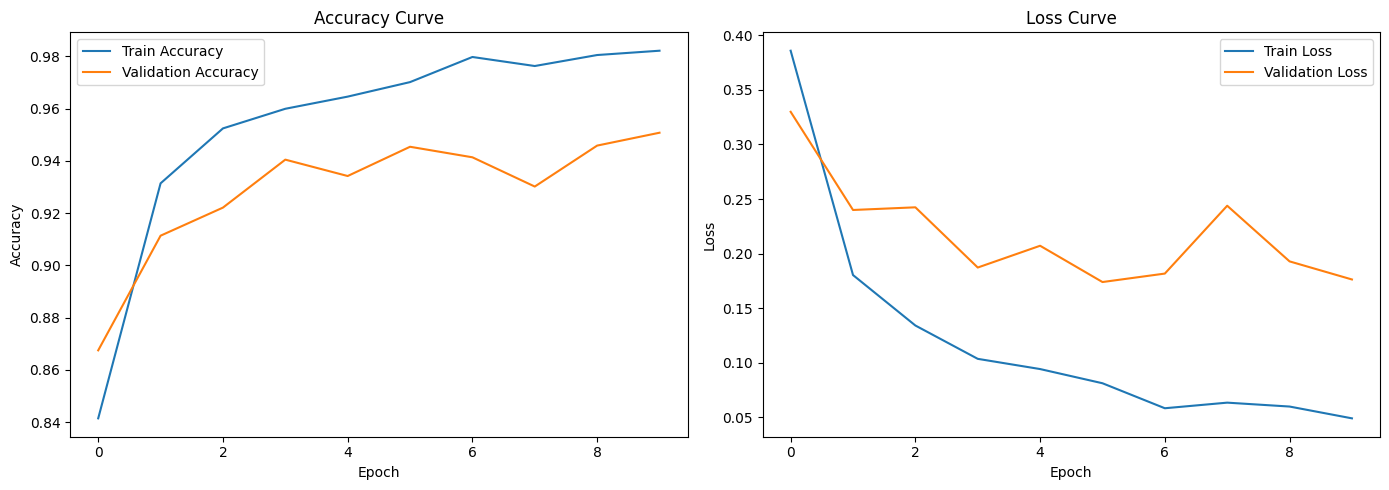

In [11]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

70/70 ━━━━━━━━━━━━━━━━━━━━ 626s 9s/step


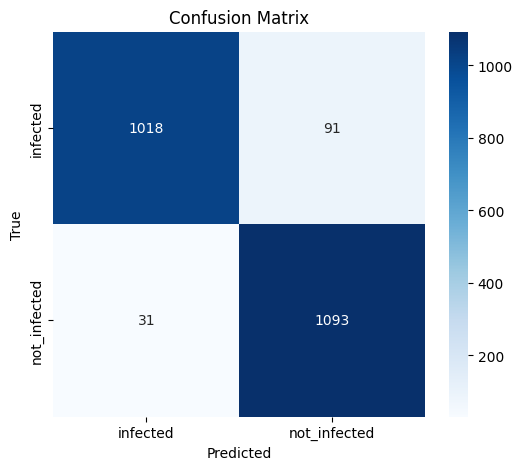

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [17]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    infected       0.97      0.92      0.94      1109
not_infected       0.92      0.97      0.95      1124

    accuracy                           0.95      2233
   macro avg       0.95      0.95      0.95      2233
weighted avg       0.95      0.95      0.95      2233



In [18]:
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))

Precision : 0.9466
Recall    : 0.9454
F1 Score  : 0.9453


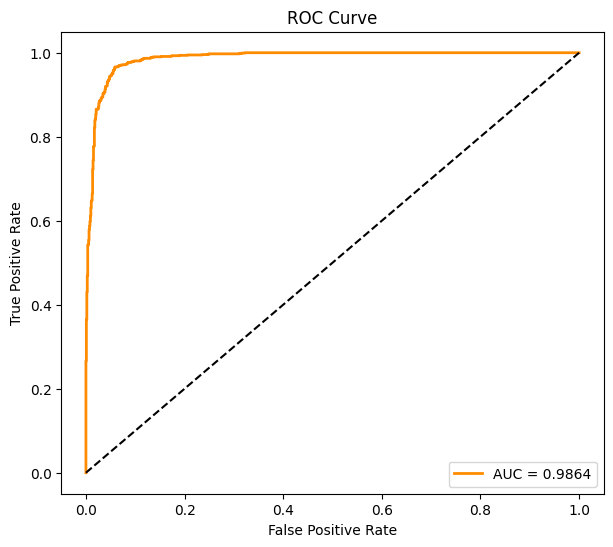

AUC Score = 0.9864490307384742


In [19]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_pred_prob[:,1]
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    linewidth=2,
    label='AUC = %0.4f' % roc_auc
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

print("AUC Score =", roc_auc)

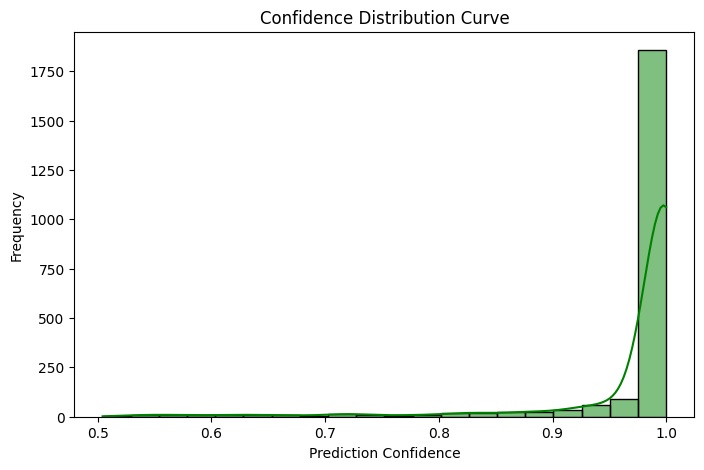

In [20]:
confidence_scores = np.max(y_pred_prob, axis=1)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence_scores,
    bins=20,
    kde=True,
    color='green'
)

plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Confidence Distribution Curve')

plt.show()